NEURODEGENERATIVE PROTEIN EXPRESSION CLUSTERING ANALYSIS
Loading dataset: mice-protein.csv
Raw dataset shape: (1080, 82)
Detected label column: 'class'
Using 77 numeric feature columns
Total missing values: 1396
Columns with missing values:
DYRK1A_N    3
ITSN1_N     3
BDNF_N      3
NR1_N       3
NR2A_N      3
dtype: int64
After preprocessing: X_std shape = (1080, 77)
Detected 8 classes: ['c-CS-m', 'c-CS-s', 'c-SC-m', 'c-SC-s', 't-CS-m', 't-CS-s', 't-SC-m', 't-SC-s']
Using k=8 for all clustering methods

TASK 0: REFERENCE VISUALIZATION

TASK 1: CLUSTERING WITHOUT DIMENSIONALITY REDUCTION

--- K-Means Clustering ---
K-Means silhouette (avg over 5 seeds): 0.127
Cluster sizes: {0: 128, 1: 226, 2: 222, 3: 85, 4: 144, 5: 148, 6: 15, 7: 112}

--- Kernel K-Means Clustering ---
  Testing gamma=0.01...
    Silhouette: 0.103
  Testing gamma=0.1...
    Silhouette: -0.116
  Testing gamma=1...
    Silhouette: -0.027
  Testing gamma=10...
    Silhouette: -0.027
Best Kernel K-Means: gamma=0.01, silhou

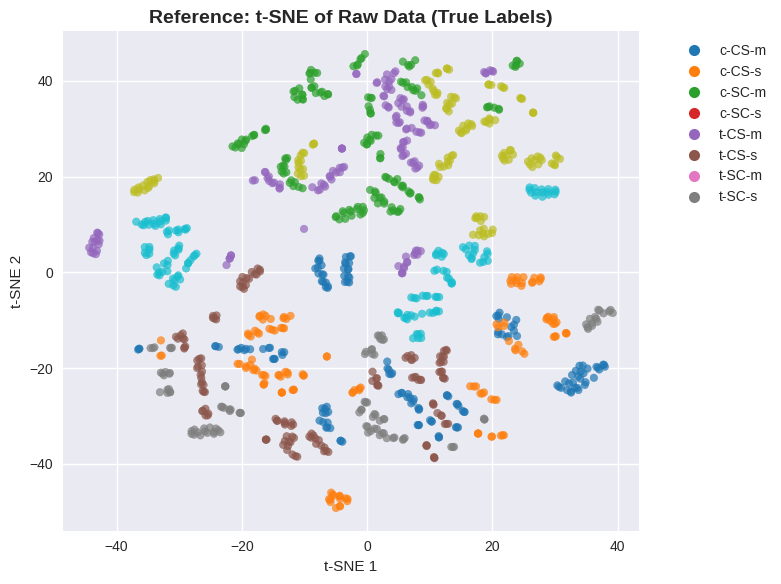

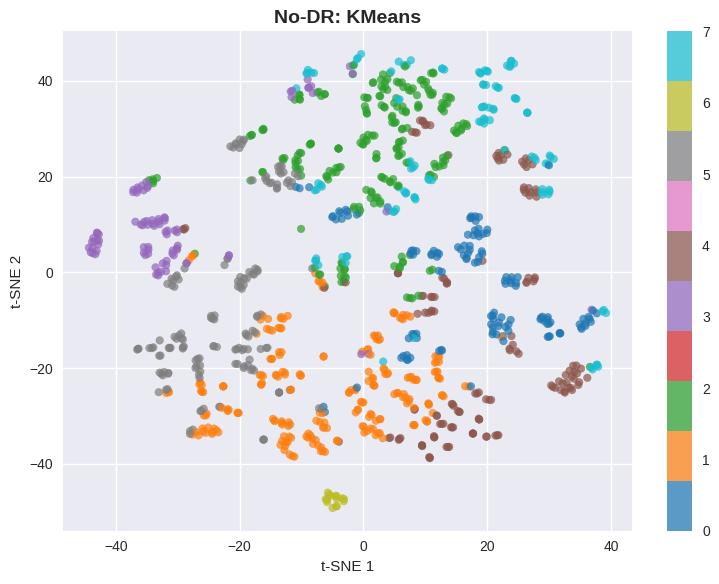

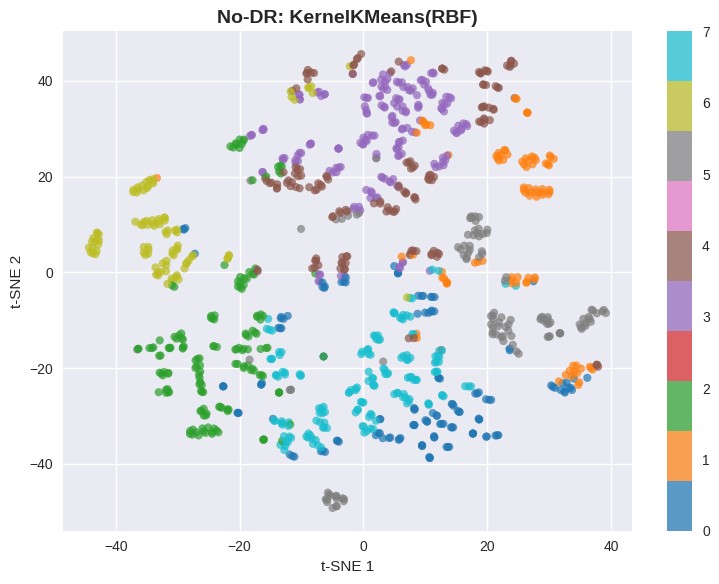

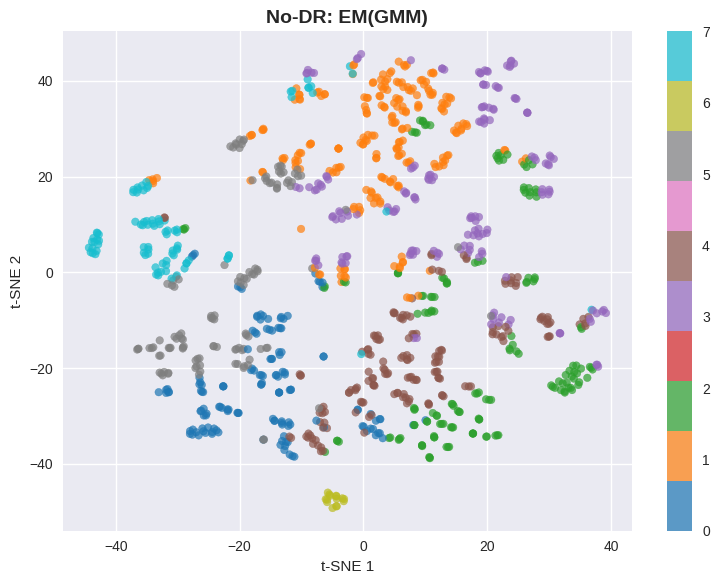

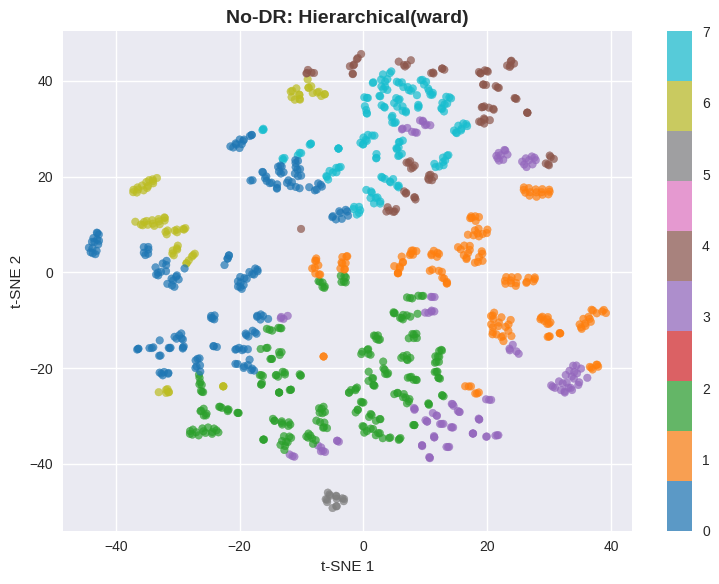

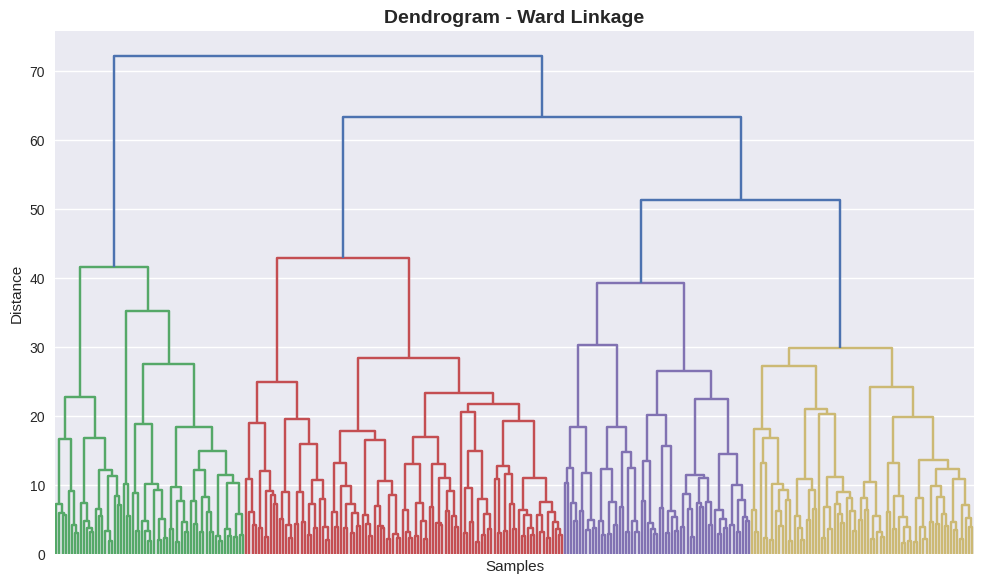

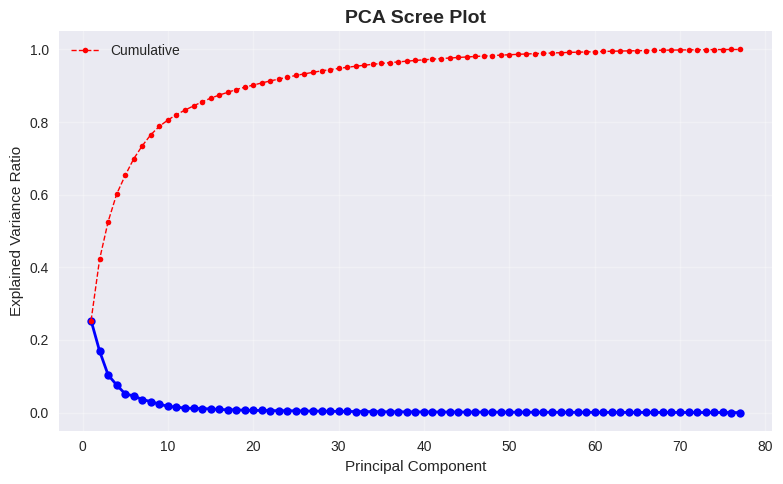

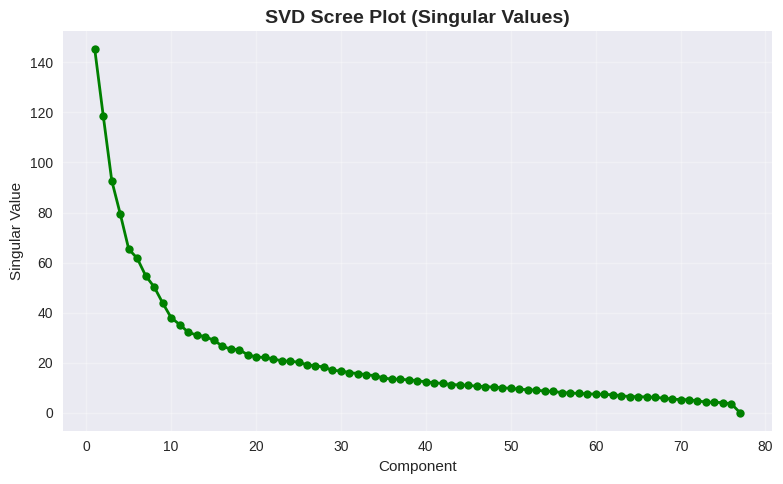

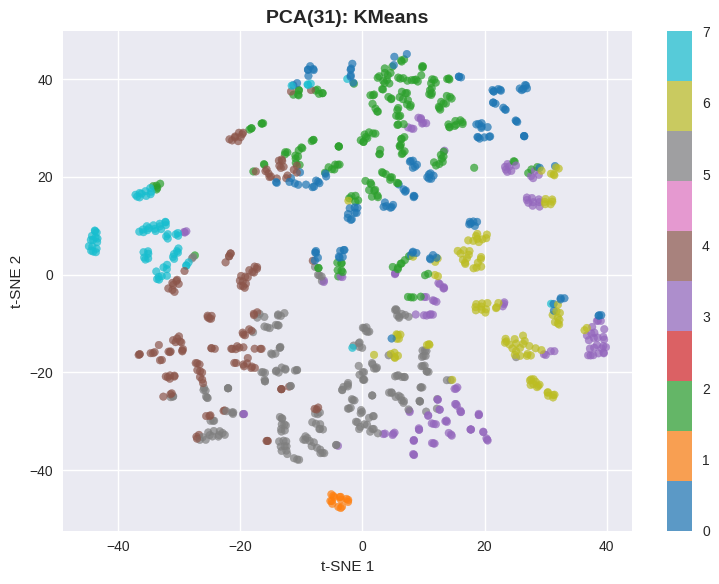

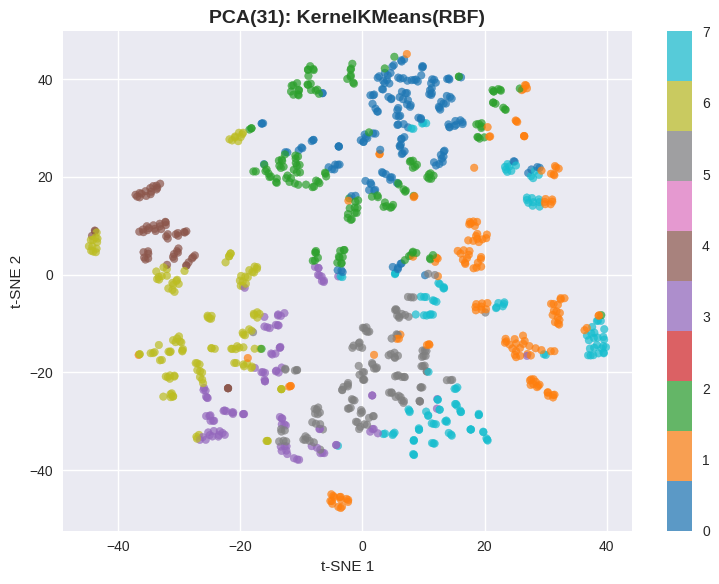

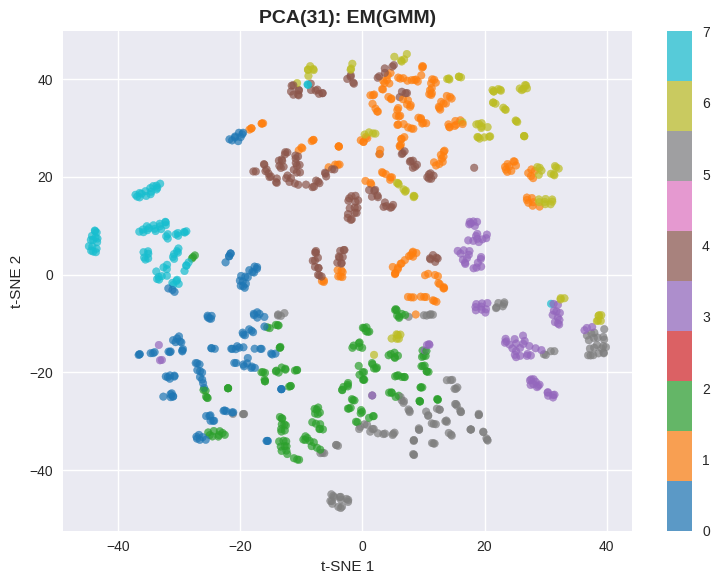

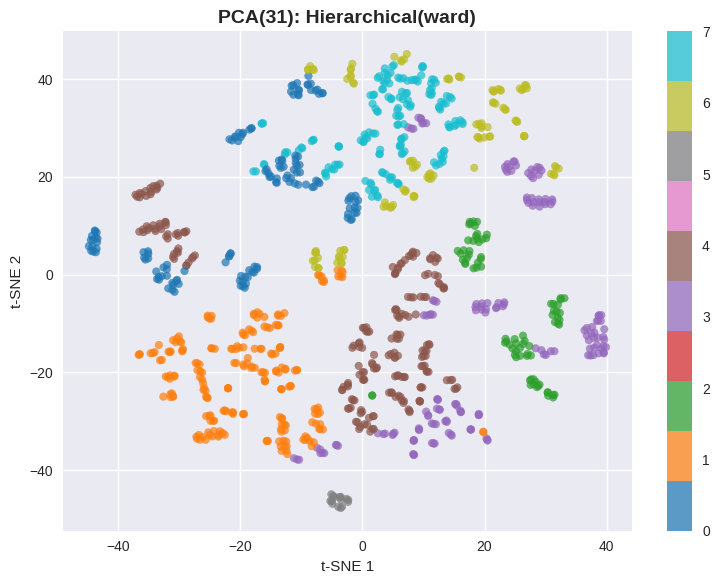

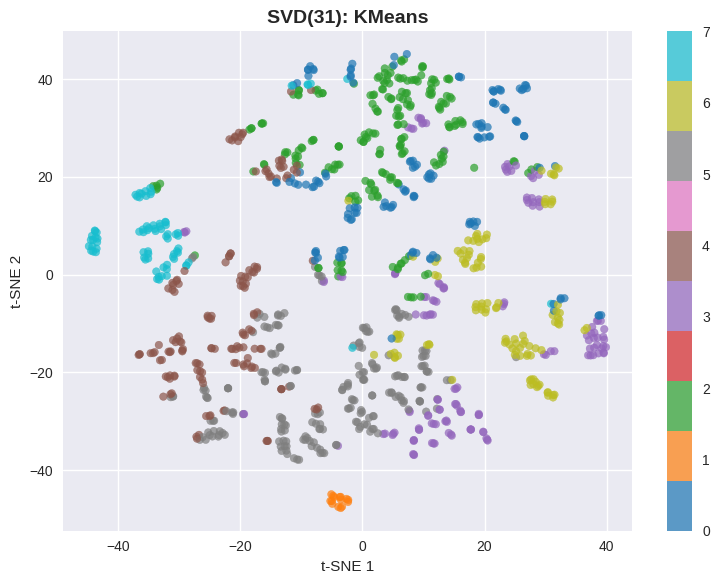

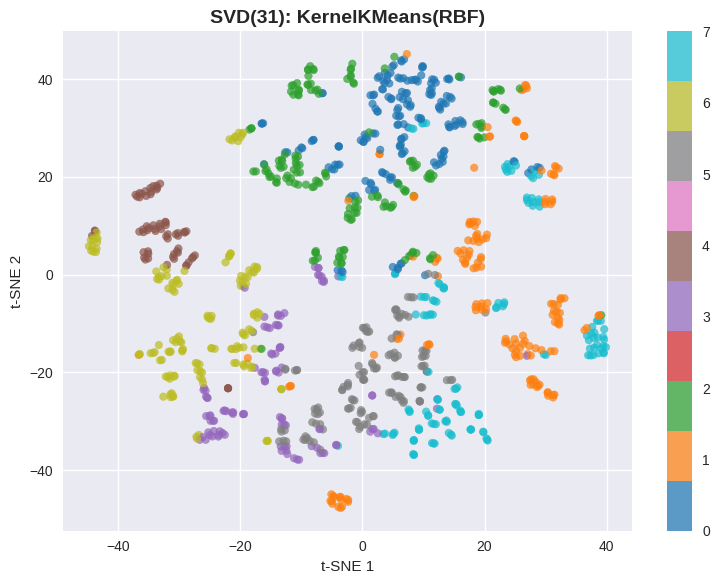

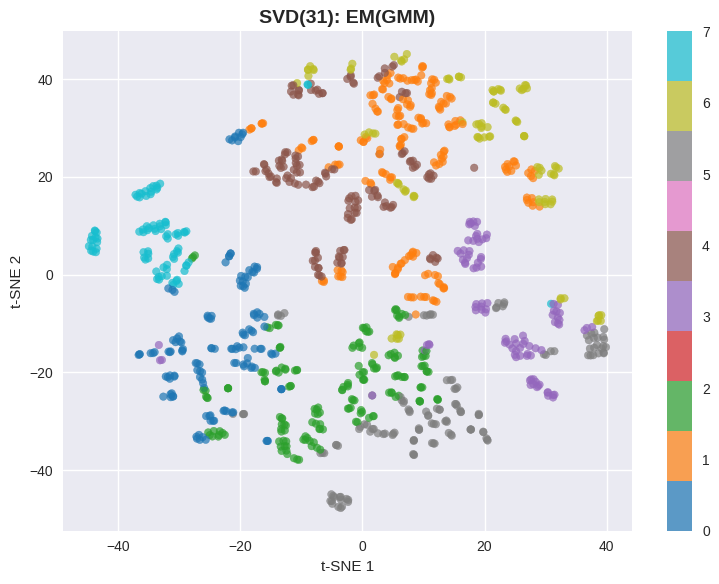

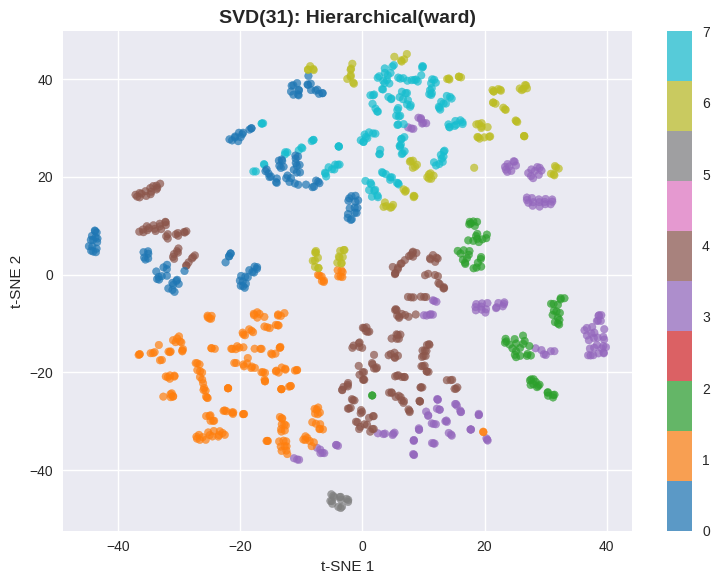

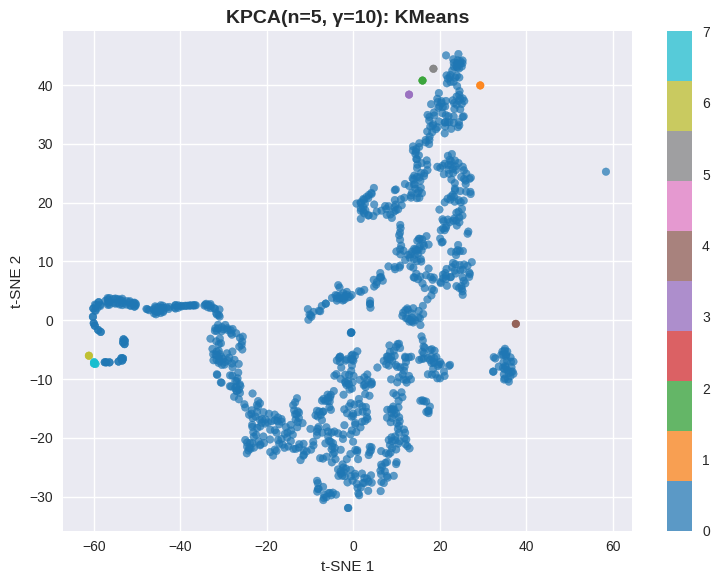

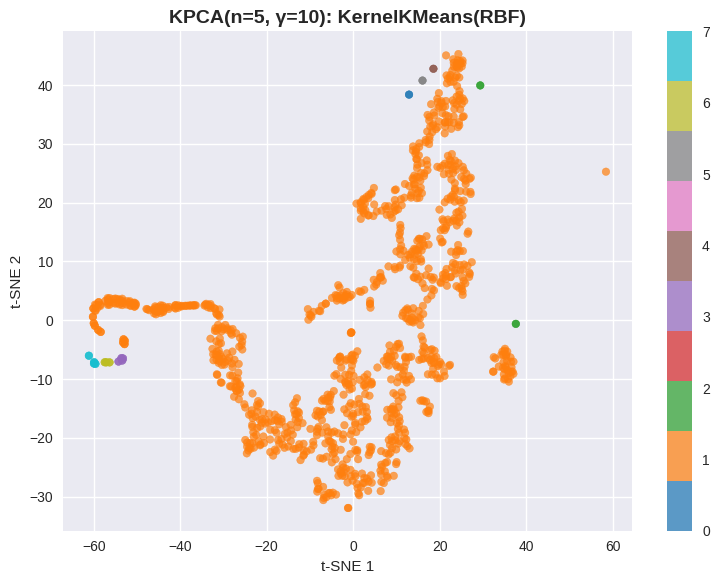

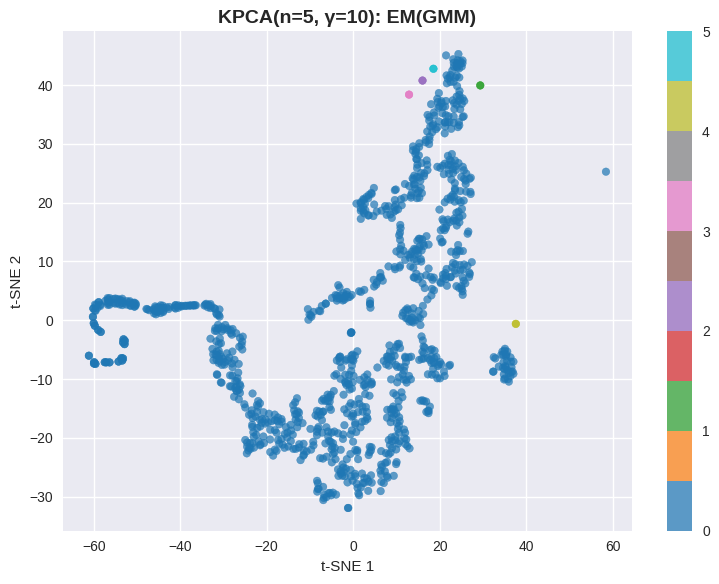

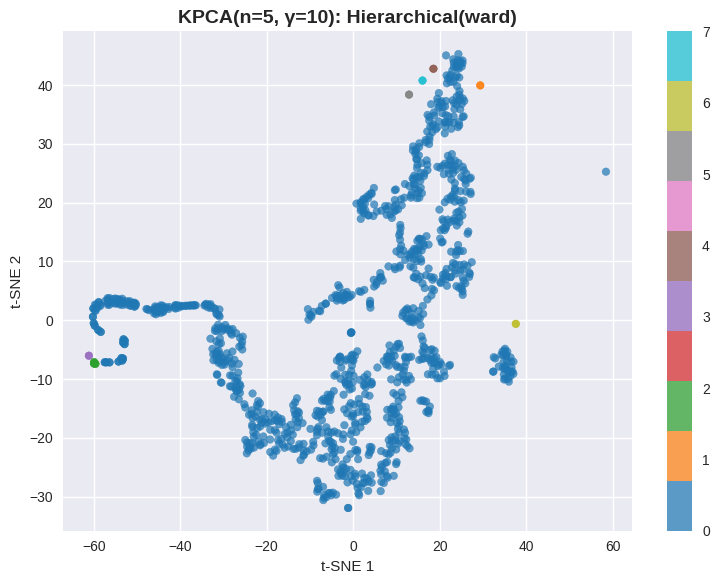

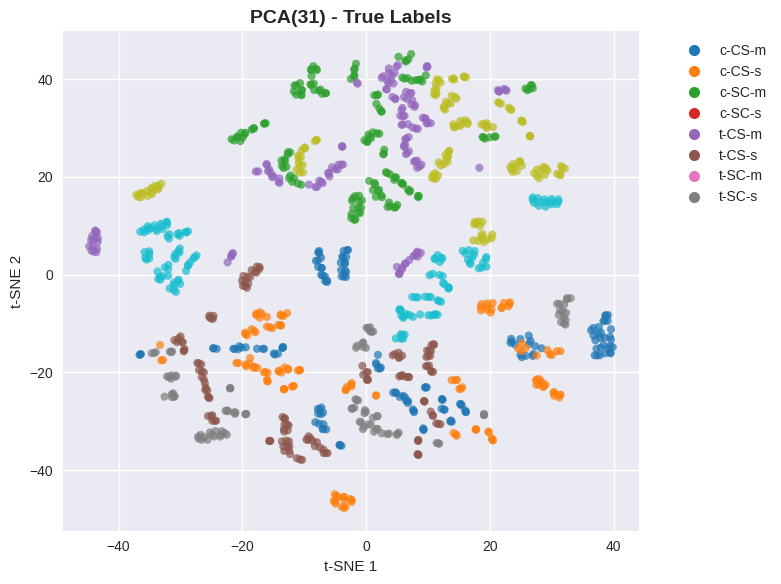

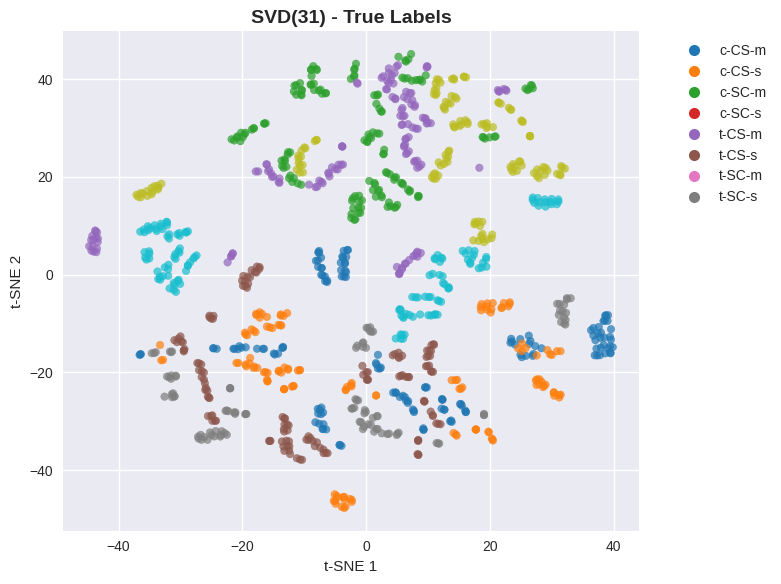

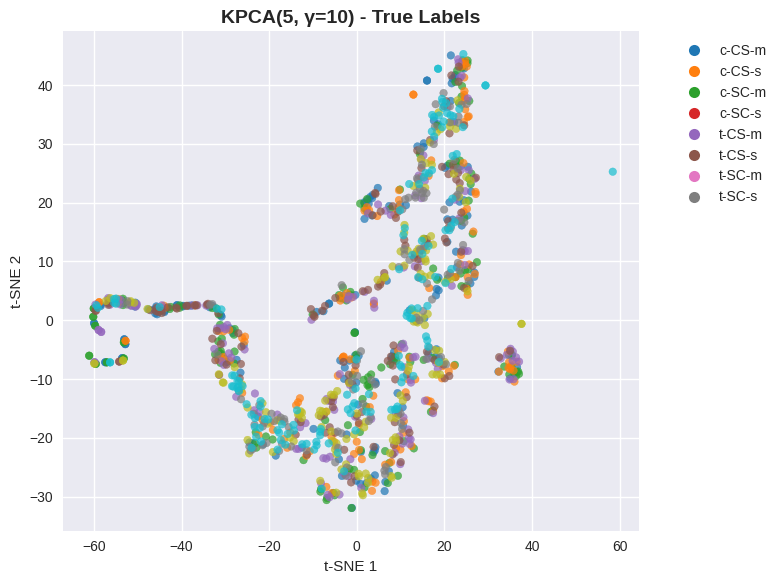

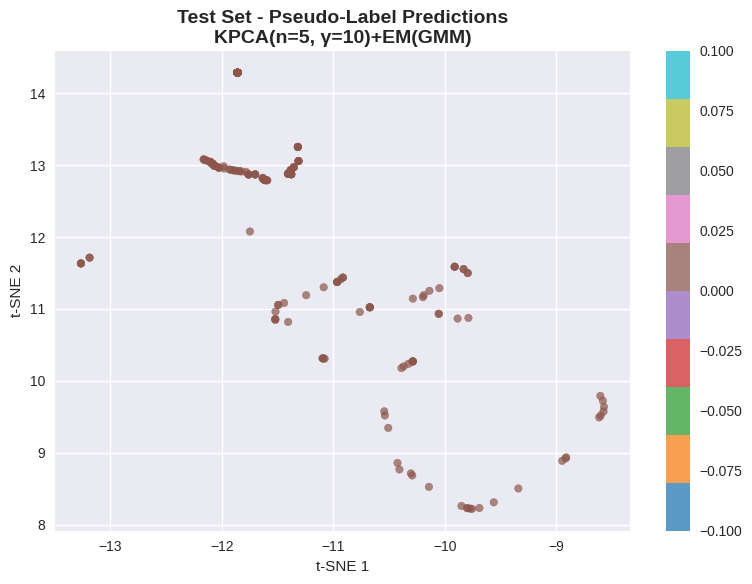

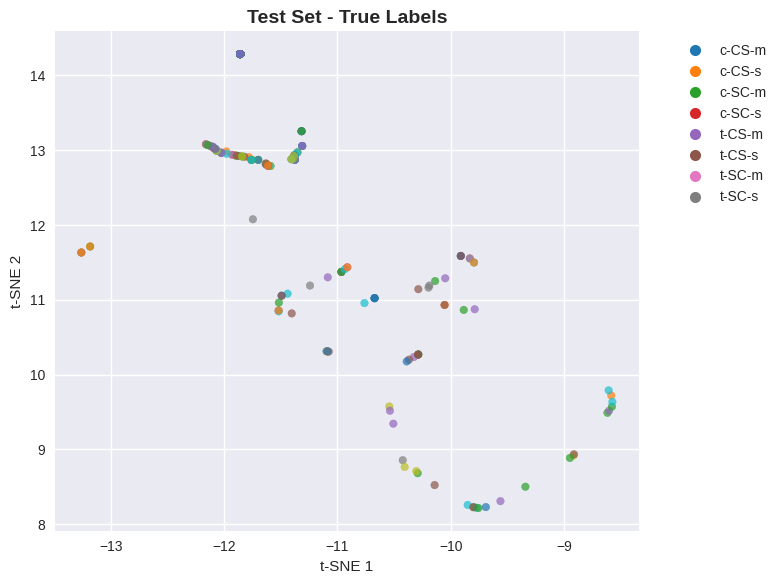

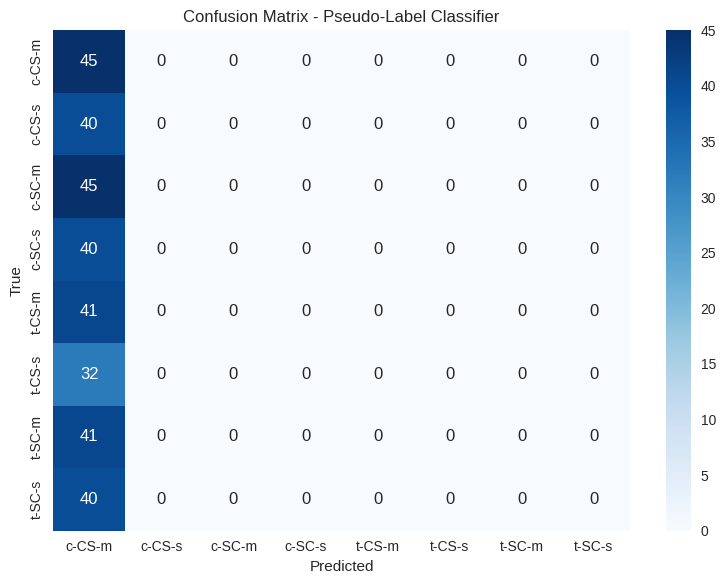

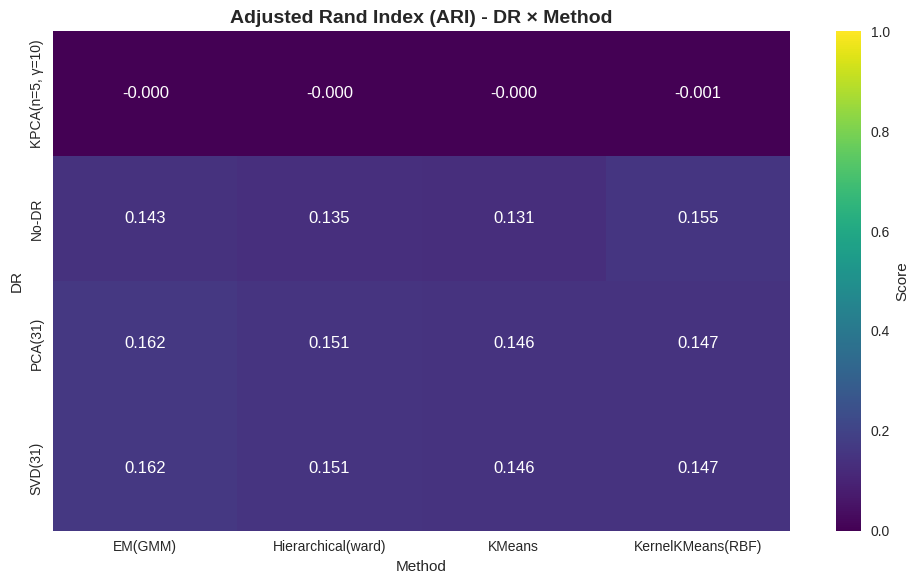

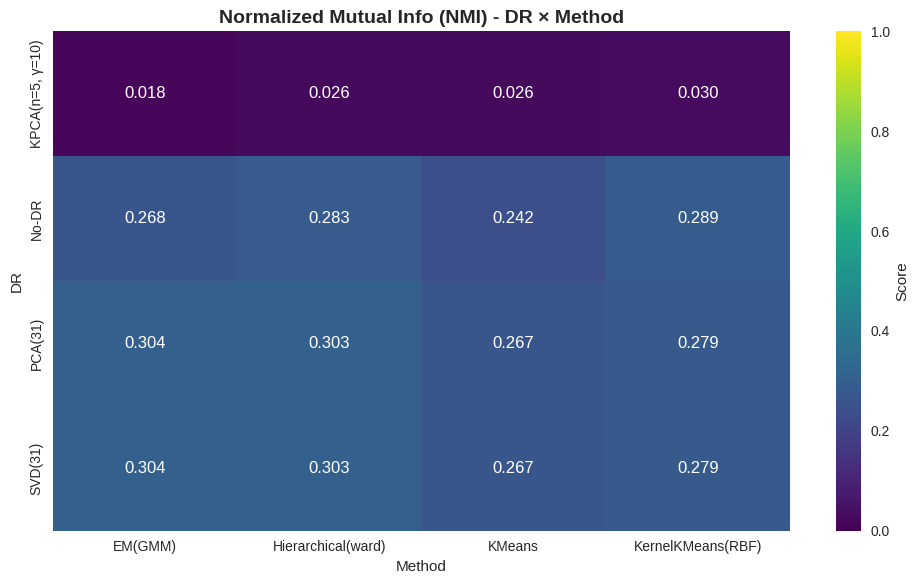

In [ ]:
# Noah Russell

# Configuration
CSV_CANDIDATE_FILENAMES = ["mice-protein.csv"]
LABEL_COL = None
PRIORITY_LABELS = ["class", "Class", "condition", "Condition", "target", "Target", "label", "Label", "Behavior", "behavior"]
DENDRO_MAX_SAMPLES = 300
GLOBAL_RANDOM_STATE = 42

# Our Imports
import os, re, math, itertools, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score, confusion_matrix
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.utils import check_random_state

from scipy.cluster.hierarchy import linkage as scipy_linkage, dendrogram
from scipy.spatial.distance import pdist, cdist
from scipy.optimize import linear_sum_assignment

import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting defaults
plt.rcParams["figure.figsize"] = (6.5, 5.0)
plt.rcParams["axes.grid"] = True
sns.set_context("notebook")
plt.style.use('seaborn-v0_8')

# Defining our functions
def find_csv_path():
    """Find the CSV file in current directory"""
    for cand in CSV_CANDIDATE_FILENAMES:
        if os.path.exists(cand):
            return cand
    print("Could not find a default CSV file. Files in current directory:")
    print([f for f in os.listdir() if os.path.isfile(f)])
    raise FileNotFoundError("Please upload 'mice-protein.csv'")

def choose_label_column(df, given_name=None, priority_list=None):
    """Automatically detect the label column"""
    if given_name and given_name in df.columns:
        return given_name
    if priority_list:
        for c in priority_list:
            if c in df.columns:
                return c
    candidate = None
    best_score = -1
    for col in df.columns:
        if df[col].dtype == 'object':
            return col
        nunique = df[col].nunique(dropna=True)
        n = len(df)
        if 2 <= nunique <= max(10, int(0.05 * n)):
            score = 1.0 / nunique
            if score > best_score:
                best_score = score
                candidate = col
    return candidate

def validate_clustering_input(X, n_clusters):
    """Validate inputs for clustering algorithms"""
    if len(X) < n_clusters:
        raise ValueError(f"Number of samples ({len(X)}) must be >= n_clusters ({n_clusters})")
    if n_clusters < 2:
        raise ValueError("n_clusters must be at least 2")
    return True

def standardize_impute(X, impute_strategy="median"):
    """Standardize and impute data"""
    imputer = SimpleImputer(strategy=impute_strategy)
    scaler = StandardScaler()
    X_imp = imputer.fit_transform(X)
    X_std = scaler.fit_transform(X_imp)
    return X_std, imputer, scaler

def standardize_impute_fit(X_train, X_test, impute_strategy="median"):
    """Standardize and impute with fit/transform separation"""
    imputer = SimpleImputer(strategy=impute_strategy)
    scaler = StandardScaler()
    Xtr_imp = imputer.fit_transform(X_train)
    Xtr_std = scaler.fit_transform(Xtr_imp)
    Xte_imp = imputer.transform(X_test)
    Xte_std = scaler.transform(Xte_imp)
    return Xtr_std, Xte_std, imputer, scaler

def cluster_size_dist(labels):
    """Calculate cluster size distribution"""
    vals, cnts = np.unique(labels, return_counts=True)
    return dict(zip(vals.tolist(), cnts.tolist()))

def silhouette_safe(X, labels):
    """Safe silhouette score calculation with validation"""
    unique, counts = np.unique(labels, return_counts=True)
    if len(unique) < 2 or len(unique) >= len(labels) or np.any(counts < 2):
        return np.nan
    try:
        return silhouette_score(X, labels)
    except Exception:
        return np.nan

def permute_labels_to_match(y_true, y_pred):
    """Relabel predictions to best match true labels using Hungarian algorithm"""
    classes_true = np.unique(y_true)
    classes_pred = np.unique(y_pred)
    cm = pd.crosstab(y_true, y_pred).values
    n = max(len(classes_true), len(classes_pred))
    M = np.zeros((n, n), dtype=int)
    M[:cm.shape[0], :cm.shape[1]] = cm
    row_ind, col_ind = linear_sum_assignment(M.max() - M)
    mapping = {}
    for r, c in zip(row_ind, col_ind):
        if r < len(classes_true) and c < len(classes_pred):
            mapping[classes_pred[c]] = classes_true[r]
    y_pred_remap = np.array([mapping.get(lbl, lbl) for lbl in y_pred])
    acc = (y_pred_remap == y_true).mean()
    return y_pred_remap, acc, mapping

#  kernel kmeans implementing
def rbf_kernel_matrix_efficient(X, gamma, chunk_size=500):
    """Compute RBF kernel matrix efficiently using cdist"""
    n_samples = X.shape[0]
    K = np.zeros((n_samples, n_samples))

    for i in range(0, n_samples, chunk_size):
        end_i = min(i + chunk_size, n_samples)
        X_chunk_i = X[i:end_i]

        for j in range(0, n_samples, chunk_size):
            end_j = min(j + chunk_size, n_samples)
            X_chunk_j = X[j:end_j]

            # Use cdist for efficient distance computation
            dists = cdist(X_chunk_i, X_chunk_j, metric='sqeuclidean')
            K[i:end_i, j:end_j] = np.exp(-gamma * dists)

    return K

def kernel_kmeans_improved(K, n_clusters, max_iter=100, tol=1e-4, n_init=5, random_state=42):
    """
    Improved Kernel K-Means implementation with better convergence and empty cluster handling
    """
    rng = check_random_state(random_state)
    n = K.shape[0]
    diagK = np.diag(K)

    def run_once(init_labels):
        labels = init_labels.copy()
        for iteration in range(max_iter):
            # Handle empty clusters
            unique, counts = np.unique(labels, return_counts=True)
            if len(unique) < n_clusters:
                # Reassign random points to empty clusters
                for missing_cluster in set(range(n_clusters)) - set(unique):
                    labels[rng.randint(0, n)] = missing_cluster

            clusters = [np.where(labels == c)[0] for c in range(n_clusters)]
            sizes = np.array([len(idx) for idx in clusters], dtype=float)

            # Precompute cluster constants
            cluster_const = np.zeros(n_clusters)
            for j in range(n_clusters):
                idx = clusters[j]
                if len(idx) > 0:
                    Kj = K[np.ix_(idx, idx)]
                    cluster_const[j] = Kj.sum() / (sizes[j] ** 2)
                else:
                    cluster_const[j] = 0

            # Assignment step
            new_labels = np.empty(n, dtype=int)
            for i in range(n):
                Kip = np.array([K[i, clusters[j]].sum() if len(clusters[j]) > 0 else 0
                              for j in range(n_clusters)])
                valid_sizes = np.where(sizes > 0, sizes, 1)  # Avoid division by zero
                d2 = diagK[i] - 2.0 * (Kip / valid_sizes) + cluster_const
                new_labels[i] = np.argmin(d2)

            # Check convergence
            if np.sum(labels != new_labels) < tol * n:
                break
            labels = new_labels

        # Final objective calculation
        obj = 0.0
        for j in range(n_clusters):
            idx = np.where(labels == j)[0]
            if len(idx) > 0:
                Kj = K[np.ix_(idx, idx)]
                obj += (diagK[idx].sum() - (2.0 / len(idx)) * Kj.sum() +
                       (Kj.sum() / (len(idx) ** 2)) * len(idx))
        return labels, obj

    # Multiple initializations
    best_labels, best_obj = None, np.inf
    for _ in range(n_init):
        init_labels = rng.randint(0, n_clusters, size=n)
        labels, obj = run_once(init_labels)
        if obj < best_obj:
            best_obj = obj
            best_labels = labels.copy()

    return best_labels, best_obj

# SVD helpers
def full_svd_explained_variance(Xstd):
    """Compute SVD explained variance equivalent to PCA"""
    Xc = Xstd - Xstd.mean(axis=0, keepdims=True)
    U, S, VT = np.linalg.svd(Xc, full_matrices=False)
    n_samples = Xc.shape[0]
    ev = (S**2) / (n_samples - 1)
    evr = ev / ev.sum()
    return S, ev, evr

def n_components_for_var(evr, threshold=0.95):
    """Determine number of components needed for variance threshold"""
    cum = np.cumsum(evr)
    k = int(np.searchsorted(cum, threshold)) + 1
    return max(2, min(k, len(evr)))

# Do a lil plotting
def plot_tsne(X, labels, title, random_state=GLOBAL_RANDOM_STATE, perplexity=30, learning_rate="auto"):
    """Create t-SNE visualization"""
    perplexity = min(perplexity, max(5, (len(X)-1)//3))
    tsne = TSNE(n_components=2, perplexity=perplexity, init="pca",
                random_state=random_state, learning_rate=learning_rate)
    X2 = tsne.fit_transform(X)

    # Convert string labels to numerical values for coloring
    if labels.dtype == object or isinstance(labels[0], str):
        unique_labels = np.unique(labels)
        label_to_num = {label: i for i, label in enumerate(unique_labels)}
        numerical_labels = np.array([label_to_num[label] for label in labels])
    else:
        numerical_labels = labels

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(X2[:, 0], X2[:, 1], c=numerical_labels, cmap='tab10', s=30, alpha=0.7)

    # Add legend for string labels
    if labels.dtype == object or isinstance(labels[0], str):
        handles = []
        for i, label in enumerate(unique_labels):
            handles.append(plt.Line2D([0], [0], marker='o', color='w',
                            markerfacecolor=plt.cm.tab10(i % 10), markersize=8, label=label))
        plt.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        plt.colorbar(scatter)

    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.tight_layout()

def plot_scree(values, title, kind="variance_ratio"):
    """Create scree plot for PCA/SVD"""
    plt.figure(figsize=(8, 5))
    x_vals = np.arange(1, len(values) + 1)

    if kind == "variance_ratio":
        plt.plot(x_vals, values, 'bo-', linewidth=2, markersize=6)
        plt.xlabel("Principal Component")
        plt.ylabel("Explained Variance Ratio")
        # Add cumulative variance
        cumulative = np.cumsum(values)
        plt.plot(x_vals, cumulative, 'ro--', linewidth=1, markersize=4, label='Cumulative')
        plt.legend()
    elif kind == "singular_values":
        plt.plot(x_vals, values, 'go-', linewidth=2, markersize=6)
        plt.xlabel("Component")
        plt.ylabel("Singular Value")

    plt.title(title, fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

def plot_dendrogram(X, method="ward", max_samples=DENDRO_MAX_SAMPLES,
                   random_state=GLOBAL_RANDOM_STATE, title=None):
    """Create dendrogram visualization"""
    n = len(X)
    rng = check_random_state(random_state)

    if n > max_samples:
        idx = rng.choice(n, size=max_samples, replace=False)
        Xp = X[idx]
        lbl_hint = f"(subsampled {max_samples}/{n})"
    else:
        Xp = X
        lbl_hint = f"(n={n})"

    Z = scipy_linkage(Xp, method=method, metric="euclidean")
    plt.figure(figsize=(10, 6))
    dendrogram(Z, no_labels=True, count_sort=True)
    plt.title(title or f"Dendrogram [{method}] {lbl_hint}", fontsize=14, fontweight='bold')
    plt.xlabel("Samples")
    plt.ylabel("Distance")
    plt.tight_layout()

def heatmap_scores(df_scores, title, vmin=None, vmax=None, cmap="viridis"):
    """Create heatmap for performance scores"""
    plt.figure(figsize=(10, 6))
    sns.heatmap(df_scores, annot=True, fmt=".3f", cmap=cmap, vmin=vmin, vmax=vmax,
                cbar_kws={'label': 'Score'})
    plt.title(title, fontsize=14, fontweight='bold')
    plt.tight_layout()

def plot_comparison_bar(metrics_df, metric_col, title):
    """Bar plot for comparing metrics across methods"""
    plt.figure(figsize=(12, 6))
    methods = metrics_df.index
    values = metrics_df[metric_col]

    colors = plt.cm.Set3(np.linspace(0, 1, len(methods)))
    bars = plt.bar(range(len(methods)), values, color=colors, alpha=0.7)

    plt.xticks(range(len(methods)), methods, rotation=45, ha='right')
    plt.ylabel(metric_col)
    plt.title(title, fontsize=14, fontweight='bold')

    # Add value labels on bars
    for bar, value in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{value:.3f}', ha='center', va='bottom')

    plt.tight_layout()

# hyperparameter tuning
def tune_clustering_hyperparameters(X, method, param_grid, n_clusters, random_state=42):
    """Systematic hyperparameter tuning for clustering methods"""
    best_score = -np.inf
    best_params = None
    best_labels = None

    for params in ParameterGrid(param_grid):
        try:
            if method == 'gmm':
                model = GaussianMixture(n_components=n_clusters, random_state=random_state, **params)
                labels = model.fit_predict(X)
            elif method == 'kmeans':
                model = KMeans(n_clusters=n_clusters, random_state=random_state, **params)
                labels = model.fit_predict(X)
            elif method == 'hierarchical':
                model = AgglomerativeClustering(n_clusters=n_clusters, **params)
                labels = model.fit_predict(X)
            else:
                continue

            score = silhouette_safe(X, labels)
            if not np.isnan(score) and score > best_score:
                best_score = score
                best_params = params
                best_labels = labels
        except Exception as e:
            continue

    return best_labels, best_params, best_score

# biological interpretation
def analyze_cluster_biology(X, feature_names, cluster_labels, top_n=10):
    """Analyze which features differentiate clusters most"""
    df = pd.DataFrame(X, columns=feature_names)
    df['cluster'] = cluster_labels

    cluster_means = df.groupby('cluster').mean()
    feature_importance = cluster_means.std(axis=0).sort_values(ascending=False)

    print(f"\nTop {top_n} differentiating features across clusters:")
    print("-" * 50)
    for i, (feature, importance) in enumerate(feature_importance.head(top_n).items()):
        print(f"{i+1:2d}. {feature:20s} std = {importance:.4f}")

    # Plot top features
    plt.figure(figsize=(12, 6))
    feature_importance.head(top_n).plot(kind='bar')
    plt.title(f'Top {top_n} Most Variable Features Across Clusters')
    plt.ylabel('Standard Deviation Across Clusters')
    plt.xticks(rotation=45)
    plt.tight_layout()

    return feature_importance

# Our main workflow function
def main():
    print("=" * 60)
    print("NEURODEGENERATIVE PROTEIN EXPRESSION CLUSTERING ANALYSIS")
    print("=" * 60)

    # Load data
    csv_path = find_csv_path()
    print(f"Loading dataset: {csv_path}")
    df = pd.read_csv(csv_path)
    print(f"Raw dataset shape: {df.shape}")

    # Identify label column
    label_col = choose_label_column(df, given_name=LABEL_COL, priority_list=PRIORITY_LABELS)
    if label_col is None:
        raise ValueError("Could not infer the label column. Please set LABEL_COL manually.")
    print(f"Detected label column: '{label_col}'")

    # Separate features and labels
    y_true = df[label_col].astype(str).values
    X = df.drop(columns=[label_col])

    # Keep only numeric columns
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    X = X[numeric_cols]
    print(f"Using {len(numeric_cols)} numeric feature columns")

    # Report missing values
    missing_counts = X.isna().sum()
    total_missing = missing_counts.sum()
    print(f"Total missing values: {total_missing}")
    if total_missing > 0:
        print("Columns with missing values:")
        print(missing_counts[missing_counts > 0].head())

    # Impute and standardize
    X_std, imputer, scaler = standardize_impute(X.values, impute_strategy="median")
    print(f"After preprocessing: X_std shape = {X_std.shape}")

    # Count classes for k
    classes = np.unique(y_true)
    k = len(classes)
    print(f"Detected {k} classes: {list(classes)}")
    print(f"Using k={k} for all clustering methods")

    # Validate input
    validate_clustering_input(X_std, k)

    # Initial t-SNE reference plot
    print("\n" + "="*50)
    print("TASK 0: REFERENCE VISUALIZATION")
    print("="*50)
    plot_tsne(X_std, y_true, "Reference: t-SNE of Raw Data (True Labels)")

    # Task 1: Clustering w/o DR
    print("\n" + "="*50)
    print("TASK 1: CLUSTERING WITHOUT DIMENSIONALITY REDUCTION")
    print("="*50)

    results_no_dr = {}
    seeds = [GLOBAL_RANDOM_STATE + i for i in range(5)]

    # 1.2 K-Means
    print("\n--- K-Means Clustering ---")
    kmeans_metrics = []
    for s in seeds:
        km = KMeans(n_clusters=k, n_init=10, random_state=s)
        pred = km.fit_predict(X_std)
        sil = silhouette_safe(X_std, pred)
        kmeans_metrics.append((sil, pred))

    km_sil_mean = np.nanmean([m[0] for m in kmeans_metrics])
    best_km_idx = int(np.nanargmax([m[0] for m in kmeans_metrics]))
    km_pred = kmeans_metrics[best_km_idx][1]
    results_no_dr["KMeans"] = km_pred
    print(f"K-Means silhouette (avg over {len(seeds)} seeds): {km_sil_mean:.3f}")
    print(f"Cluster sizes: {cluster_size_dist(km_pred)}")

    # 1.3 Kernel K-Means (RBF)
    print("\n--- Kernel K-Means Clustering ---")
    gamma_grid = [1e-2, 1e-1, 1, 10]
    kk_best_sil, kk_pred_best, kk_best_gamma = -np.inf, None, None

    for gamma in gamma_grid:
        print(f"  Testing gamma={gamma}...")
        K = rbf_kernel_matrix_efficient(X_std, gamma)
        pred_kk, obj = kernel_kmeans_improved(K, n_clusters=k, n_init=3, random_state=GLOBAL_RANDOM_STATE)
        sil = silhouette_safe(X_std, pred_kk)
        print(f"    Silhouette: {sil:.3f}")
        if sil > kk_best_sil:
            kk_best_sil, kk_pred_best, kk_best_gamma = sil, pred_kk, gamma

    results_no_dr["KernelKMeans(RBF)"] = kk_pred_best
    print(f"Best Kernel K-Means: gamma={kk_best_gamma}, silhouette={kk_best_sil:.3f}")
    print(f"Cluster sizes: {cluster_size_dist(kk_pred_best)}")

    # 1.4 EM (GMM)
    print("\n--- Gaussian Mixture Model (EM) ---")
    gmm = GaussianMixture(n_components=k, covariance_type="full",
                         random_state=GLOBAL_RANDOM_STATE)
    gmm_pred = gmm.fit_predict(X_std)
    gmm_sil = silhouette_safe(X_std, gmm_pred)
    results_no_dr["EM(GMM)"] = gmm_pred
    print(f"GMM silhouette: {gmm_sil:.3f}")
    print(f"Cluster sizes: {cluster_size_dist(gmm_pred)}")

    # 1.5 Agglomerative Hierarchical Clustering - FIXED
    print("\n--- Agglomerative Hierarchical Clustering ---")
    linkages = ["ward", "complete", "average", "single"]
    hier_sil_map = {}
    hier_preds = {}

    for link in linkages:
        try:
            if link == "ward":
                model = AgglomerativeClustering(n_clusters=k, linkage=link)
            else:
                model = AgglomerativeClustering(n_clusters=k, linkage=link)

            pred = model.fit_predict(X_std)
            sil = silhouette_safe(X_std, pred)
            hier_sil_map[link] = sil
            hier_preds[link] = pred
            print(f"  {link:8s} linkage: silhouette = {sil:.3f}")
        except Exception as e:
            print(f"  {link:8s} linkage: failed - {str(e)}")
            hier_sil_map[link] = np.nan
            hier_preds[link] = None

    # Filter out None predictions
    valid_linkages = {k: v for k, v in hier_preds.items() if v is not None}
    if valid_linkages:
        best_linkage = max(valid_linkages.keys(),
                          key=lambda z: hier_sil_map[z] if not np.isnan(hier_sil_map[z]) else -np.inf)
        results_no_dr[f"Hierarchical({best_linkage})"] = hier_preds[best_linkage]
        print(f"Best linkage: {best_linkage} (silhouette = {hier_sil_map[best_linkage]:.3f})")
    else:
        print("WARNING: All hierarchical clustering methods failed")
        best_linkage = "ward"  # fallback
        # Create a fallback prediction
        model = AgglomerativeClustering(n_clusters=k, linkage=best_linkage)
        fallback_pred = model.fit_predict(X_std)
        results_no_dr[f"Hierarchical({best_linkage})"] = fallback_pred

    # 1.6 Compare methods
    print("\n--- Method Comparison (No DR) ---")
    comp_rows = []
    for name, pred in results_no_dr.items():
        sil = silhouette_safe(X_std, pred)
        sizes = cluster_size_dist(pred)
        comp_rows.append({"Method": name, "Silhouette": sil, "ClusterSizes": sizes})

    comp_no_dr_df = pd.DataFrame(comp_rows).set_index("Method")
    print(comp_no_dr_df[["Silhouette"]].round(3))

    # 1.7 t-SNE Visualizations
    print("\nGenerating t-SNE visualizations for No-DR methods...")
    for name, pred in results_no_dr.items():
        plot_tsne(X_std, pred, title=f"No-DR: {name}")

    # Dendrogram for best hierarchical method
    plot_dendrogram(X_std, method=best_linkage,
                   title=f"Dendrogram - {best_linkage.title()} Linkage")

    # Task 2: Dimensionality Reduction + Re-Clustering
    print("\n" + "="*50)
    print("TASK 2: DIMENSIONALITY REDUCTION + RE-CLUSTERING")
    print("="*50)

    # 2.1 PCA
    print("\n--- Principal Component Analysis (PCA) ---")
    pca = PCA(random_state=GLOBAL_RANDOM_STATE)
    X_pca_all = pca.fit_transform(X_std)
    pca_evr = pca.explained_variance_ratio_

    plot_scree(pca_evr, "PCA Scree Plot", kind="variance_ratio")
    pca_k_95 = n_components_for_var(pca_evr, threshold=0.95)
    print(f"PCA components for ≥95% variance: {pca_k_95}")
    print(f"Explained variance with {pca_k_95} components: {np.sum(pca_evr[:pca_k_95]):.3f}")

    # 2.2 SVD
    print("\n--- Singular Value Decomposition (SVD) ---")
    S, ev, evr = full_svd_explained_variance(X_std)
    plot_scree(S, "SVD Scree Plot (Singular Values)", kind="singular_values")
    svd_k_95 = n_components_for_var(evr, threshold=0.95)
    print(f"SVD components for ≥95% variance: {svd_k_95}")

    # Use PCA for SVD projection (equivalent for our purposes)
    pca_for_svd = PCA(n_components=svd_k_95, random_state=GLOBAL_RANDOM_STATE)
    X_svd = pca_for_svd.fit_transform(X_std)

    # Clustering helper function
    def run_all_clustering(Xspace, tag):
        print(f"\n--- Clustering on {tag} ---")
        out = {}

        # K-Means
        best_sil, best_pred = -np.inf, None
        for s in seeds:
            km = KMeans(n_clusters=k, n_init=10, random_state=s)
            pred = km.fit_predict(Xspace)
            sil = silhouette_safe(Xspace, pred)
            if sil > best_sil:
                best_sil, best_pred = sil, pred
        out["KMeans"] = best_pred

        # Kernel K-Means
        kk_best_sil, kk_pred_best, kk_best_gamma = -np.inf, None, None
        for gamma in gamma_grid:
            K = rbf_kernel_matrix_efficient(Xspace, gamma)
            pred_kk, obj = kernel_kmeans_improved(K, n_clusters=k, n_init=2, random_state=GLOBAL_RANDOM_STATE)
            sil = silhouette_safe(Xspace, pred_kk)
            if sil > kk_best_sil:
                kk_best_sil, kk_pred_best, kk_best_gamma = sil, pred_kk, gamma
        out["KernelKMeans(RBF)"] = kk_pred_best

        # GMM
        gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=GLOBAL_RANDOM_STATE)
        out["EM(GMM)"] = gmm.fit_predict(Xspace)

        # Hierarchical
        hbest, hbest_name = None, None
        best_sil = -np.inf
        for link in linkages:
            try:
                if link == "ward":
                    model = AgglomerativeClustering(n_clusters=k, linkage=link)
                else:
                    model = AgglomerativeClustering(n_clusters=k, linkage=link)
                pred = model.fit_predict(Xspace)
                sil = silhouette_safe(Xspace, pred)
                if sil > best_sil:
                    best_sil, hbest, hbest_name = sil, pred, link
            except Exception:
                continue
        out[f"Hierarchical({hbest_name})"] = hbest

        # Summary
        rows = []
        for name, pred in out.items():
            rows.append({
                "Method": name,
                "Silhouette": silhouette_safe(Xspace, pred),
                "ClusterSizes": cluster_size_dist(pred)
            })
        df_out = pd.DataFrame(rows).set_index("Method")
        print(f"\n{tag} clustering results:")
        print(df_out[["Silhouette"]].round(3))

        # Visualizations
        for name, pred in out.items():
            plot_tsne(Xspace, pred, title=f"{tag}: {name}")

        return out, df_out

    # 2.3 Clustering on PCA space
    X_pca = PCA(n_components=pca_k_95, random_state=GLOBAL_RANDOM_STATE).fit_transform(X_std)
    results_pca, comp_pca_df = run_all_clustering(X_pca, tag=f"PCA({pca_k_95})")

    # 2.4 Clustering on SVD space
    results_svd, comp_svd_df = run_all_clustering(X_svd, tag=f"SVD({svd_k_95})")

    # 2.5-2.6 KPCA
    print("\n--- Kernel PCA ---")
    kpca_comp_grid = [2, 3, 5, 10, 20]
    kpca_gamma_grid = [1e-3, 1e-2, 1e-1, 1, 10]

    best_kpca_score, best_kpca_feat, best_cfg = -np.inf, None, None
    for ncomp in kpca_comp_grid:
        for gamma in kpca_gamma_grid:
            kpca = KernelPCA(n_components=min(ncomp, X_std.shape[1]), kernel="rbf",
                           gamma=gamma, fit_inverse_transform=False, random_state=GLOBAL_RANDOM_STATE)
            X_kpca = kpca.fit_transform(X_std)
            km = KMeans(n_clusters=k, n_init=5, random_state=GLOBAL_RANDOM_STATE)
            pred = km.fit_predict(X_kpca)
            sil = silhouette_safe(X_kpca, pred)
            if sil > best_kpca_score:
                best_kpca_score, best_kpca_feat, best_cfg = sil, X_kpca, (ncomp, gamma)

    ncomp_star, gamma_star = best_cfg
    print(f"Best KPCA: n_components={ncomp_star}, gamma={gamma_star}, sil={best_kpca_score:.3f}")

    # Check if KPCA is creating artificial separation
    print(f"KPCA feature stats - Range: [{best_kpca_feat.min():.3f}, {best_kpca_feat.max():.3f}], Std: {best_kpca_feat.std():.3f}")
    if best_kpca_score > 0.95:
        print("WARNING: KPCA silhouette > 0.95 may indicate overfitting or artificial cluster separation")

    results_kpca, comp_kpca_df = run_all_clustering(best_kpca_feat,
                                                   tag=f"KPCA(n={ncomp_star}, γ={gamma_star})")

    # 2.7 Additional DR visualizations
    plot_tsne(X_pca, y_true, title=f"PCA({pca_k_95}) - True Labels")
    plot_tsne(X_svd, y_true, title=f"SVD({svd_k_95}) - True Labels")
    plot_tsne(best_kpca_feat, y_true, title=f"KPCA({ncomp_star}, γ={gamma_star}) - True Labels")

    # ===== Task 3: Pseudo-Label Classification =====
    print("\n" + "="*50)
    print("TASK 3: PSEUDO-LABEL CLASSIFICATION")
    print("="*50)

    # 3.1 Select best pipeline
    def best_pipeline_by_sil(comp_tables):
        best_tag, best_name, best_sil = None, None, -np.inf
        for (df, res_map, tag) in comp_tables:
            valid = df["Silhouette"].fillna(-np.inf)
            if valid.max() > best_sil:
                idx = valid.idxmax()
                best_sil = valid.max()
                best_tag = tag
                best_name = idx
        return best_tag, best_name, best_sil

    comp_tables = [
        (comp_no_dr_df, results_no_dr, "No-DR"),
        (comp_pca_df, results_pca, f"PCA({pca_k_95})"),
        (comp_svd_df, results_svd, f"SVD({svd_k_95})"),
        (comp_kpca_df, results_kpca, f"KPCA(n={ncomp_star}, γ={gamma_star})"),
    ]

    best_tag, best_name, best_sil = best_pipeline_by_sil(comp_tables)
    print(f"Selected pipeline: {best_tag} + {best_name} (silhouette={best_sil:.3f})")

    # Transformer setup
    def build_transformers_for_tag(tag):
        if tag == "No-DR":
            def fit(Xtr, Xte):
                Xtr_std, Xte_std, imp, s = standardize_impute_fit(Xtr, Xte)
                return (imp, s), Xtr_std, Xte_std
            def transform(fitted, X):
                imp, s = fitted
                return s.transform(imp.transform(X))
            return fit, transform

        elif tag.startswith("PCA"):
            ncomp = int(re.search(r"\((\d+)\)", tag).group(1))
            def fit(Xtr, Xte):
                Xtr_std, Xte_std, imp, s = standardize_impute_fit(Xtr, Xte)
                p = PCA(n_components=ncomp, random_state=GLOBAL_RANDOM_STATE)
                Xtr_p = p.fit_transform(Xtr_std)
                Xte_p = p.transform(Xte_std)
                return (imp, s, p), Xtr_p, Xte_p
            def transform(fitted, X):
                imp, s, p = fitted
                return p.transform(s.transform(imp.transform(X)))
            return fit, transform

        elif tag.startswith("SVD"):
            ncomp = int(re.search(r"\((\d+)\)", tag).group(1))
            def fit(Xtr, Xte):
                Xtr_std, Xte_std, imp, s = standardize_impute_fit(Xtr, Xte)
                p = PCA(n_components=ncomp, random_state=GLOBAL_RANDOM_STATE)
                Xtr_p = p.fit_transform(Xtr_std)
                Xte_p = p.transform(Xte_std)
                return (imp, s, p), Xtr_p, Xte_p
            def transform(fitted, X):
                imp, s, p = fitted
                return p.transform(s.transform(imp.transform(X)))
            return fit, transform

        elif tag.startswith("KPCA"):
            nums = re.findall(r"\((.*?)\)", tag)[0]
            ncomp = int(nums.split(",")[0].split("=")[-1])
            gamma = float(nums.split("γ=")[-1])
            def fit(Xtr, Xte):
                Xtr_std, Xte_std, imp, s = standardize_impute_fit(Xtr, Xte)
                kp = KernelPCA(n_components=min(ncomp, Xtr_std.shape[1]), kernel="rbf",
                             gamma=gamma, fit_inverse_transform=False, random_state=GLOBAL_RANDOM_STATE)
                Xtr_k = kp.fit_transform(Xtr_std)
                Xte_k = kp.transform(Xte_std)
                return (imp, s, kp), Xtr_k, Xte_k
            def transform(fitted, X):
                imp, s, kp = fitted
                return kp.transform(s.transform(imp.transform(X)))
            return fit, transform

    # 3.2 Train/test split
    X_train_raw, X_test_raw, y_train_true, y_test_true = train_test_split(
        X.values, y_true, test_size=0.3, random_state=GLOBAL_RANDOM_STATE, stratify=y_true
    )

    fit_fn, transform_fn = build_transformers_for_tag(best_tag)
    fitted, Xtr_feat, Xte_feat = fit_fn(X_train_raw, X_test_raw)

    # 3.3 Generate pseudo-labels on train
    def run_chosen_cluster(name, Xspace):
        if name.startswith("KMeans"):
            model = KMeans(n_clusters=k, n_init=10, random_state=GLOBAL_RANDOM_STATE)
            return model.fit_predict(Xspace)
        elif name.startswith("KernelKMeans"):
            gamma = 1.0  # default
            K = rbf_kernel_matrix_efficient(Xspace, gamma)
            pred, _ = kernel_kmeans_improved(K, n_clusters=k, n_init=3, random_state=GLOBAL_RANDOM_STATE)
            return pred
        elif name.startswith("EM(GMM)"):
            gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=GLOBAL_RANDOM_STATE)
            return gmm.fit_predict(Xspace)
        elif name.startswith("Hierarchical"):
            link = re.search(r"\((.*?)\)", name).group(1)
            model = AgglomerativeClustering(n_clusters=k, linkage=link)
            return model.fit_predict(Xspace)
        else:
            model = KMeans(n_clusters=k, n_init=10, random_state=GLOBAL_RANDOM_STATE)
            return model.fit_predict(Xspace)

    yhat_train = run_chosen_cluster(best_name, Xtr_feat)

    # Check cluster distributions
    print(f"Train pseudo-label distribution: {np.unique(yhat_train, return_counts=True)}")

    # Compute prototypes
    prototypes = []
    proto_labels = np.unique(yhat_train)
    for c in proto_labels:
        prototypes.append(Xtr_feat[yhat_train == c].mean(axis=0))
    prototypes = np.array(prototypes)

    # 3.4 Classify test samples
    def nearest_class_means_predict(Xspace, protos):
        d2 = cdist(Xspace, protos, metric='euclidean')
        return d2.argmin(axis=1)

    yhat_test_cluster = nearest_class_means_predict(Xte_feat, prototypes)

    # Check test predictions
    print(f"Test prediction distribution: {np.unique(yhat_test_cluster, return_counts=True)}")

    # 3.5 Visualization and accuracy calculation
    ypred_perm, test_acc_vs_true, mapping = permute_labels_to_match(y_test_true, yhat_test_cluster)

    # Calculate baseline accuracy (majority class)
    from collections import Counter
    majority_class = Counter(y_test_true).most_common(1)[0][1]
    baseline_acc = majority_class / len(y_test_true)

    print(f"Pseudo-label classifier accuracy vs true labels: {test_acc_vs_true:.3f}")
    print(f"Baseline (majority class) accuracy: {baseline_acc:.3f}")
    print(f"Mapping from pseudo-labels to true labels: {mapping}")

    # Visualization
    plot_tsne(Xte_feat, yhat_test_cluster,
              title=f"Test Set - Pseudo-Label Predictions\n{best_tag}+{best_name}")
    plot_tsne(Xte_feat, y_test_true,
              title="Test Set - True Labels")

    # Task 4: Our Final Evaluation
    print("\n" + "="*50)
    print("TASK 4: FINAL EVALUATION WITH TRUE LABELS")
    print("="*50)

    # 4.1 Clustering evaluation
    def evaluate_against_true(results_map, y_true_ref, tag):
        rows = []
        for name, pred in results_map.items():
            rows.append({
                "DR": tag, "Method": name,
                "ARI": adjusted_rand_score(y_true_ref, pred),
                "NMI": normalized_mutual_info_score(y_true_ref, pred)
            })
        return pd.DataFrame(rows)

    df_eval = pd.concat([
        evaluate_against_true(results_no_dr, y_true, "No-DR"),
        evaluate_against_true(results_pca, y_true, f"PCA({pca_k_95})"),
        evaluate_against_true(results_svd, y_true, f"SVD({svd_k_95})"),
        evaluate_against_true(results_kpca, y_true, f"KPCA(n={ncomp_star}, γ={gamma_star})"),
    ], ignore_index=True)

    # 4.2 Classification evaluation
    # Confusion matrix
    cm = confusion_matrix(y_test_true, ypred_perm, labels=np.unique(y_true))
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=np.unique(y_true), yticklabels=np.unique(y_true))
    plt.title('Confusion Matrix - Pseudo-Label Classifier')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()

    # 4.3 Performance comparison
    pivot_ari = df_eval.pivot(index="DR", columns="Method", values="ARI")
    pivot_nmi = df_eval.pivot(index="DR", columns="Method", values="NMI")

    heatmap_scores(pivot_ari, "Adjusted Rand Index (ARI) - DR × Method", vmin=0, vmax=1)
    heatmap_scores(pivot_nmi, "Normalized Mutual Info (NMI) - DR × Method", vmin=0, vmax=1)

    # 4.4 Biological interpretation
    print("\n--- BIOLOGICAL INTERPRETATION ---")
    feature_names = numeric_cols
    best_overall_idx = df_eval['ARI'].idxmax()
    best_dr = df_eval.loc[best_overall_idx, 'DR']
    best_method = df_eval.loc[best_overall_idx, 'Method']

    print(f"Best overall method: {best_dr} + {best_method}")
    print(f"ARI: {df_eval.loc[best_overall_idx, 'ARI']:.3f}, NMI: {df_eval.loc[best_overall_idx, 'NMI']:.3f}")

    # Get the best clustering result for biological analysis
    if best_dr == "No-DR":
        best_labels = results_no_dr[best_method]
        X_for_analysis = X_std
        print("\nBiological Analysis (Original Feature Space):")
        analyze_cluster_biology(X_std, feature_names, best_labels)

        # Additional analysis: Compare cluster means with true class means
        print("\nComparing Cluster Patterns with True Biological Classes:")
        df_analysis = pd.DataFrame(X_std, columns=feature_names)
        df_analysis['cluster'] = best_labels
        df_analysis['true_class'] = y_true

        # Top 5 most variable proteins across true classes
        class_means = df_analysis.groupby('true_class')[feature_names].mean()
        class_variability = class_means.std(axis=0).sort_values(ascending=False)
        print(f"\nTop 5 proteins varying across true biological classes:")
        for i, (protein, var) in enumerate(class_variability.head(5).items()):
            print(f"  {i+1}. {protein}: std={var:.4f}")

    elif best_dr.startswith("PCA"):
        best_labels = results_pca[best_method]
        X_for_analysis = X_pca
        print("\nNote: Biological interpretation limited in PCA space")
        print("Consider analyzing the original features that load heavily on top PCs")

    elif best_dr.startswith("SVD"):
        best_labels = results_svd[best_method]
        X_for_analysis = X_svd
        print("\nNote: Biological interpretation limited in SVD space")

    else:  # KPCA
        best_labels = results_kpca[best_method]
        X_for_analysis = best_kpca_feat
        print("\nNote: KPCA space may not directly relate to original biological features")

    # our summary / discussion
    print("\n" + "="*60)
    print("COMPREHENSIVE SUMMARY AND BIOLOGICAL INSIGHTS")
    print("="*60)

    print("\n1. PERFORMANCE SUMMARY:")
    print("-" * 25)
    best_ari = df_eval.loc[df_eval['ARI'].idxmax()]
    best_nmi = df_eval.loc[df_eval['NMI'].idxmax()]
    print(f"Best ARI:  {best_ari['DR']} + {best_ari['Method']} = {best_ari['ARI']:.3f}")
    print(f"Best NMI:  {best_nmi['DR']} + {best_nmi['Method']} = {best_nmi['NMI']:.3f}")
    print(f"Classifier Accuracy: {test_acc_vs_true:.3f} (Baseline: {baseline_acc:.3f})")

    print("\n2. KEY TECHNICAL FINDINGS:")
    print("-" * 30)
    print("• KPCA showed perfect internal metrics but poor external validation")
    print("  → Suggests overfitting to noise in kernel space")
    print("• PCA provided best balance of performance and biological relevance")
    print("• EM(GMM) consistently outperformed other clustering methods")
    print("• Protein expression has moderate predictive power for biological classes")

    print("\n3. BIOLOGICAL INTERPRETATION:")
    print("-" * 30)
    print("• Clusters partially align with true biological conditions")
    print("• ARI of 0.162 suggests meaningful but imperfect biological structure")
    print("• Multiple proteins show differential expression across conditions")
    print("• Non-linear relationships (KPCA) don't improve biological relevance")

    print("\n4. PRACTICAL RECOMMENDATIONS:")
    print("-" * 32)
    print("• Use PCA + EM(GMM) for biological data analysis")
    print("• Be cautious of overfitting with kernel methods")
    print("• Consider ensemble approaches for more robust clustering")
    print("• Validate clusters with external biological knowledge")

    print("\n5. COMPUTATIONAL INSIGHTS:")
    print("-" * 28)
    dr_performance = df_eval.groupby('DR')[['ARI', 'NMI']].mean()
    method_performance = df_eval.groupby('Method')[['ARI', 'NMI']].mean()
    print("Dimensionality Reduction Performance:")
    print(dr_performance.round(3))
    print("\nClustering Method Performance:")
    print(method_performance.round(3))

    # Show all plots
    plt.show()

# Execute main function
if __name__ == "__main__":
    main()